
Reading Intan Technologies RHD Data File, Version 1.5

Found 0 amplifier channels.
Found 0 auxiliary input channels.
Found 0 supply voltage channels.
Found 8 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.



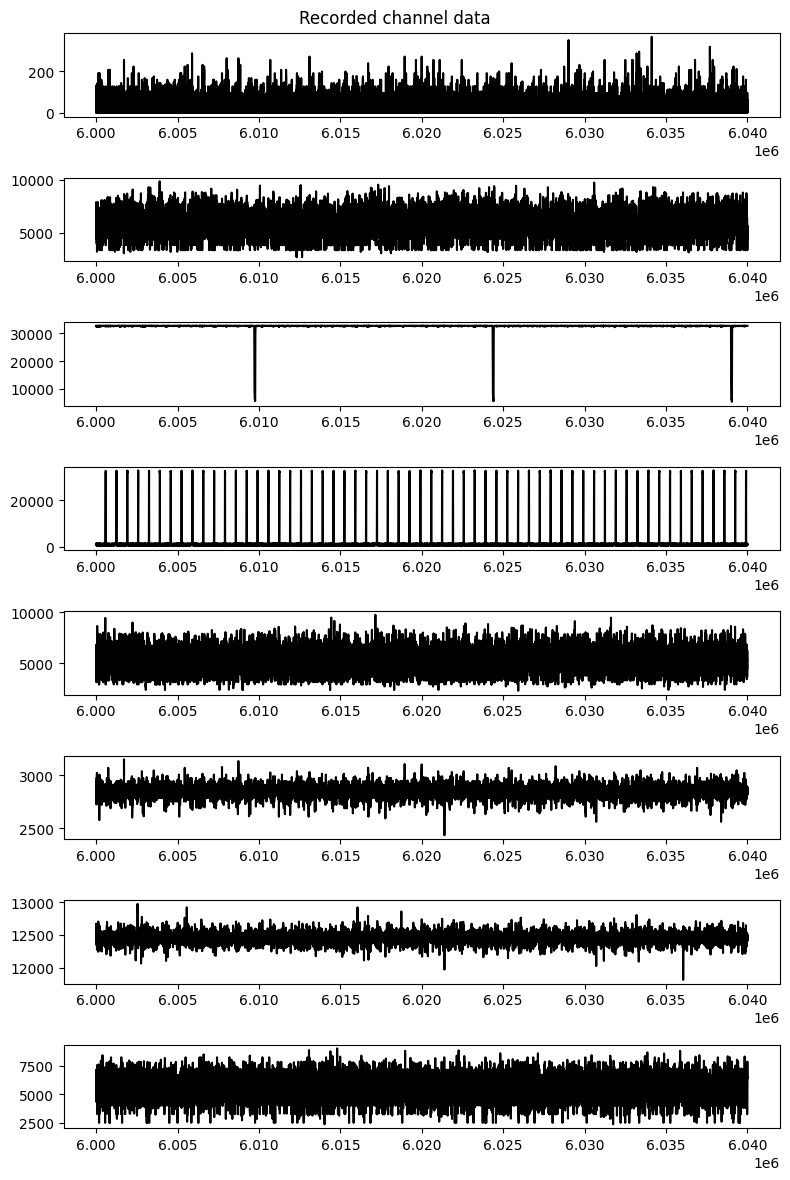

Getting transitions from 0:7691.47195 s
Found 10400 raw triggers for scope
Getting transitions from 0:7691.47195 s
Found 2348 raw triggers for photodiode
Getting transitions from 0:7691.47195 s
Found 229569 raw triggers for camera
Getting transitions from 0:7691.47195 s
Found 1347915 raw triggers for treadmill
Found Suite2P Path /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/field_depth20um/suite2p!
Found scope fps from Experiment.xml file: 1.366
Did not realign scope times
Saved manifest to /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/synced/twop_manifest.json


array([  40.6442 ,   41.37605,   42.108  , ..., 7650.79205, 7651.524  ,
       7652.25595], shape=(10400,))

In [1]:
%load_ext autoreload
%autoreload 2
from twop_pipeline.intan.IntanData import *
from twop_pipeline.twop.getSuite2POutput import *
from twop_pipeline.twop.TwoPSync import *

intan_path = '/mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1'
s2p_path = intan_path

intan_data = IntanData(intan_path, twop_channel=2, camera_channel=3, pd_channel=5, treadmill_channel=6,
                        plot_intan=True, intan_plot_start_s=300, intan_plot_end_s=302,
                          save_plot=True, plot_save_filename= os.path.join(os.path.join(intan_path, 'channels_plot.png')))
s2p_out = Suite2POutput(s2p_path)

sync = TwoPSync(s2p_output=s2p_out, intan_data=intan_data, out_dir_name='synced')
sync.run()

frame_times_synced = np.load(os.path.join(intan_path, 'synced', 'frame_times_synced.npy'))
frame_times_synced

In [ ]:
from twop_pipeline.intan.intan_io import *

export_signal_times(intan_data, out_dir='synced', export_times=True)
synced_folderpath = os.path.join(intan_path,'synced')
camera_times_raw = np.load(os.path.join(synced_folderpath, 'camera_times_raw.npy'))
camera_times_raw

Exporting signals to /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/synced


array([  31.2491 ,   31.28505,   31.32125, ..., 7683.62565, 7683.65895,
       7683.6923 ], shape=(229569,))

In [ ]:
from twop_pipeline.twop.TwoPAnalyze import *

s2p_path = '/mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10'
ex_s2p = Suite2POutput(s2p_path)
get_deltaF(s2p_out=ex_s2p)
get_deltaF(suite2p_path=s2p_path)

Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/suite2p!
Found scope fps from Experiment.xml file: 29.16


/home/gianna/Desktop/PythonProjects/2P_pipeline_v1/twop_pipeline/twop/compute_twop.py:66: RuntimeWarning: invalid value encountered in divide
  deltaF = (rawF - baseline) / baseline


array([[ 0.04053238,  0.73774948, -0.031458  , ...,  0.04680851,
         0.08510643, -0.12036474],
       [-0.01360544, -0.00680272,  0.00340136, ...,  0.01706485,
        -0.01365188, -0.0443686 ],
       [ 0.01613643,  0.01494818,  0.00291766, ...,  0.20153148,
        -0.02339162,  1.15130188],
       ...,
       [-0.01551904,  0.6686548 ,  0.40593759, ..., -0.00119169,
         0.01268914,  0.00426827],
       [-0.018454  , -0.00878753, -0.00374188, ..., -0.01336562,
        -0.00496982,  0.0059774 ],
       [ 0.0182698 ,  0.17953262,  0.01361334, ..., -0.01296462,
        -0.01586732,  0.00373234]], shape=(144, 36000))